%% [markdown]
# EDA & dataset suitability — GRN-Prior Expression Embedding Benchmark

A tight exploratory pass over the RA PBMC pseudobulk and the DoRothEA graph, to answer:
**is this dataset suitable for the question, and what can/can't it show?** The experiments
themselves live in `scripts/03_run_experiments.py`; this notebook is the narrative EDA layer.

Headline that falls out below: **cell type separates cleanly and linearly; disease does not,
and is aliased with donor** — which is why we treat cell type as the trustworthy readout and
disease as suggestive only.

In [1]:
# %%
import sys
from pathlib import Path

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
sys.path.insert(0, str(Path.cwd().parent / "src"))
from grn_bench.data import load_aligned  # noqa: E402

In [4]:
d = load_aligned()
X, obs, genes, tfs = d["X"], d["obs"], d["genes"], d["tfs"]
print(f"pseudobulk: {X.shape[0]} samples x {X.shape[1]} genes (aligned to graph)")
print(f"donors={obs.donor_id.nunique()}  cell_types={obs.cell_type.nunique()}")

pseudobulk: 500 samples x 8376 genes (aligned to graph)
donors=36  cell_types=15


%% [markdown]
## 1. Composition & balance
Donor × cell-type coverage (how many cells went into each pseudobulk sample), and the
disease / sex balance that determines what confounds we must control.

/var/folders/pl/xsc6t6nn1037vpwc8ksl46h00000gn/T/ipykernel_39445/1419148531.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  piv = obs.pivot_table(index="donor_id", columns="cell_type", values="n_cells", aggfunc="sum")


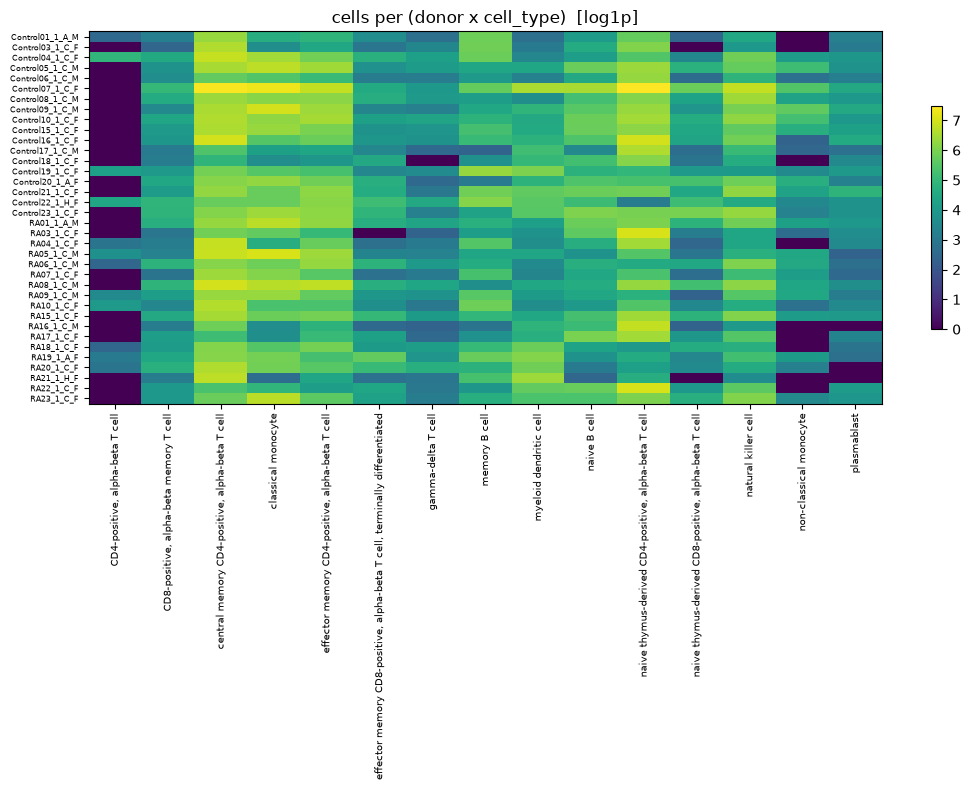

In [5]:
# %%
piv = obs.pivot_table(index="donor_id", columns="cell_type", values="n_cells", aggfunc="sum")
fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(np.log1p(piv.fillna(0).values), aspect="auto", cmap="viridis")
ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels(piv.columns, rotation=90, fontsize=7)
ax.set_yticks(range(piv.shape[0])); ax.set_yticklabels(piv.index, fontsize=6)
ax.set_title("cells per (donor x cell_type)  [log1p]"); fig.colorbar(im, shrink=0.6)
plt.tight_layout(); plt.show()

In [6]:
# %%
donor_meta = obs.drop_duplicates("donor_id")
print("donors per disease:\n", donor_meta.disease.value_counts().to_string())
print("\ndonor sex x disease:\n", donor_meta.groupby(["disease", "sex"]).size().to_string())
print(f"\ncells/group: min={obs.n_cells.min()} median={int(obs.n_cells.median())} max={obs.n_cells.max()}")

donors per disease:
 disease
normal                  18
rheumatoid arthritis    18

donor sex x disease:
 disease               sex   
normal                female    12
                      male       6
rheumatoid arthritis  female    12
                      male       6

cells/group: min=10 median=104 max=1788


/var/folders/pl/xsc6t6nn1037vpwc8ksl46h00000gn/T/ipykernel_39445/286866002.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print("\ndonor sex x disease:\n", donor_meta.groupby(["disease", "sex"]).size().to_string())


%% [markdown]
Balanced **18 RA / 18 normal**, **12F/6M in both arms** (no sex–disease confound), single assay.
The design is **between-subjects**: each donor is only RA *or* normal, so disease is confounded
with donor identity. This is the key limitation the evaluation must respect.

%% [markdown]
## 2. Library size (QC sanity)

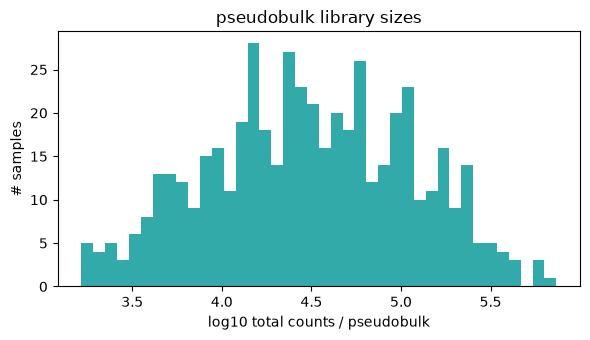

In [7]:
# %%
lib = np.asarray(d["counts"].sum(1)).ravel()
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(np.log10(lib), bins=40, color="#3aa"); ax.set_xlabel("log10 total counts / pseudobulk")
ax.set_ylabel("# samples"); ax.set_title("pseudobulk library sizes"); plt.tight_layout(); plt.show()

%% [markdown]
## 3. The confound, visually: PCA & UMAP of the pseudobulk
If cell type is a strong linear signal and disease is not, a 2-D projection should separate
**cell type** but mix **disease** and show **donor** substructure.

In [8]:
# %%
from sklearn.decomposition import PCA  # noqa: E402
from sklearn.preprocessing import StandardScaler  # noqa: E402

In [9]:
Xs = StandardScaler().fit_transform(X)
pcs = PCA(n_components=30, random_state=0).fit_transform(Xs)

In [10]:
def scatter_by(coords, key, title, ax, legend=False):
    cats = obs[key].astype("category")
    codes = cats.cat.codes
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=codes, cmap="tab20", s=14, alpha=0.8)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    if legend and cats.cat.categories.size <= 16:
        handles = [plt.Line2D([], [], marker="o", ls="", color=plt.cm.tab20(i / 20))
                   for i in range(cats.cat.categories.size)]
        ax.legend(handles, list(cats.cat.categories), fontsize=5, loc="best", ncol=1)

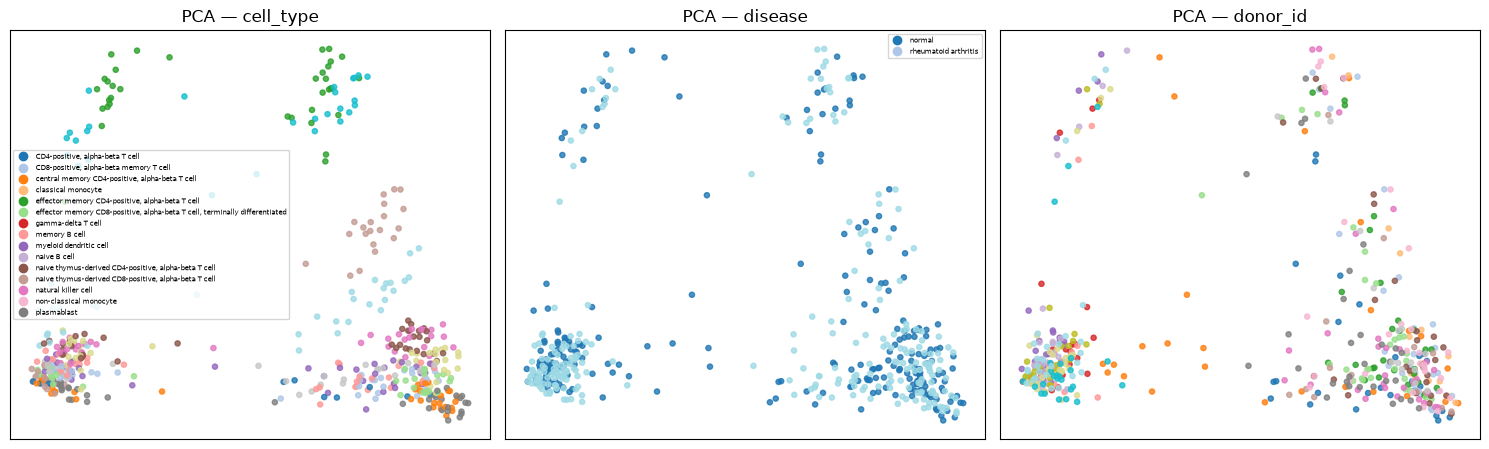

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, key, leg in zip(axes, ["cell_type", "disease", "donor_id"], [True, True, False]):
    scatter_by(pcs, key, f"PCA — {key}", ax, legend=leg)
plt.tight_layout(); plt.show()

In [12]:
# %%
import umap  # noqa: E402

/Users/barteks/workai/projects/grn-prior-benchmark/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/barteks/workai/projects/grn-prior-benchmark/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


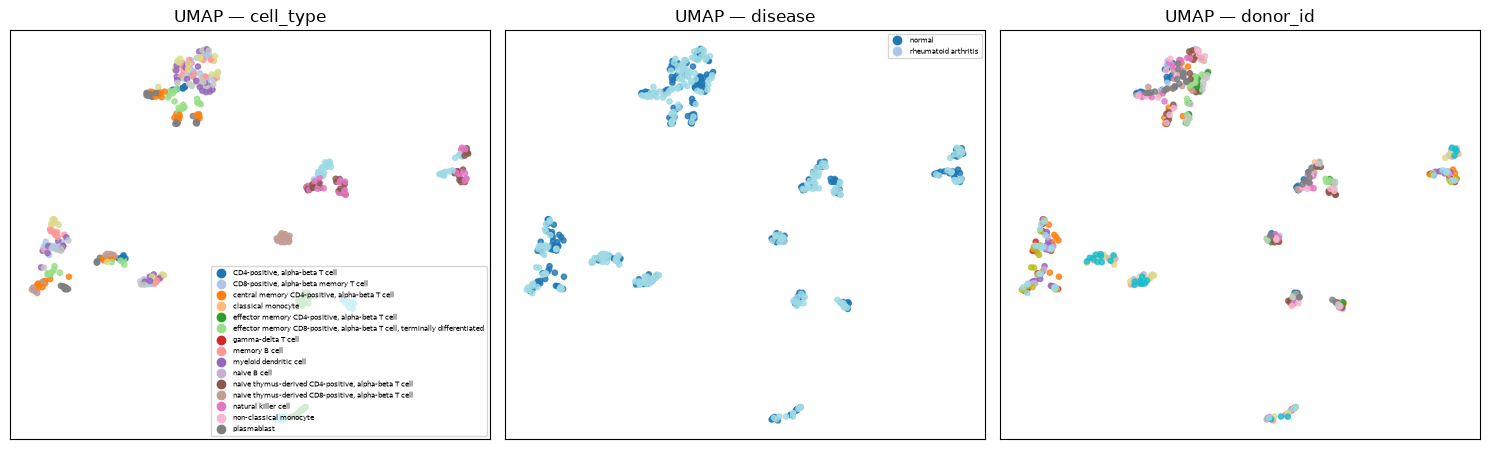

In [13]:
um = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=0).fit_transform(pcs)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, key, leg in zip(axes, ["cell_type", "disease", "donor_id"], [True, True, False]):
    scatter_by(um, key, f"UMAP — {key}", ax, legend=leg)
plt.tight_layout(); plt.show()

%% [markdown]
As expected: **cell type** forms clean clusters, **disease** is thoroughly mixed, and **donor**
shows fine substructure inside each cell type. This is the whole reason cell type is our primary
readout and disease is suggestive-only, always split by donor.

%% [markdown]
## 4. DoRothEA graph structure

input genes=8376  TFs(hidden)=411  edges=30609  density=0.0089


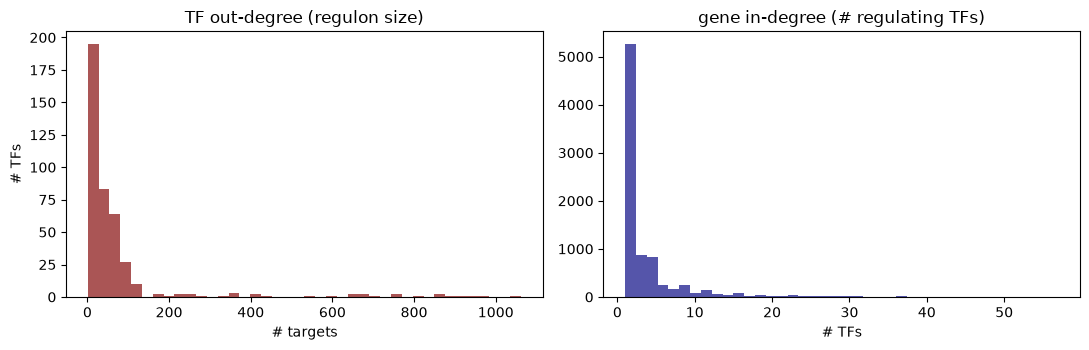

In [14]:
# %%
g = d["graph"]
out_deg = np.bincount(g["real_cols"], minlength=len(tfs))
in_deg = np.bincount(g["real_rows"], minlength=len(genes))
print(f"input genes={len(genes)}  TFs(hidden)={len(tfs)}  edges={len(g['real_rows'])}  "
      f"density={len(g['real_rows'])/(len(genes)*len(tfs)):.4f}")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(out_deg, bins=40, color="#a55"); axes[0].set_title("TF out-degree (regulon size)")
axes[0].set_xlabel("# targets"); axes[0].set_ylabel("# TFs")
axes[1].hist(in_deg, bins=40, color="#55a"); axes[1].set_title("gene in-degree (# regulating TFs)")
axes[1].set_xlabel("# TFs"); plt.tight_layout(); plt.show()

%% [markdown]
## 5. Headline result
Cell-type macro-F1 (donor-grouped CV, full data). Full sweep + interpretation in
`results/tables/results.csv` and `memo/memo.md`.

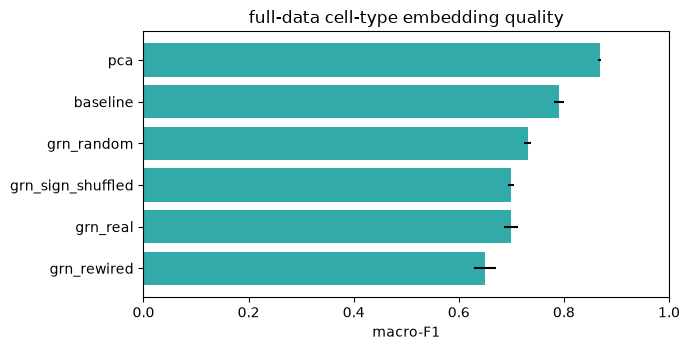

In [15]:
# %%
res = pd.read_csv(Path.cwd().parent / "results" / "tables" / "results.csv")
full = res[(res.condition == "full") & (res.task == "cell_type")].sort_values("mean")
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(full.model, full["mean"], xerr=full["std"], color="#3aa")
ax.set_xlim(0, 1); ax.set_xlabel("macro-F1"); ax.set_title("full-data cell-type embedding quality")
plt.tight_layout(); plt.show()

%% [markdown]
**Takeaway.** PCA and the unconstrained baseline beat every DoRothEA-masked variant, and the
real graph does not beat its same-density controls (random ≥ real). The GRN prior adds
complexity without adding usable biological signal on this dataset — a fair negative result.